# Homework12

Exercises with Neural Networks

## Goals

- Get familiar with neural network setup, design, data preparation and training process
- Practice setting up the ingredients and parameters for the training loop
- Experiment with neural networks for classification tasks


### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework

In [3]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/nn_utils.py
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/imagenette.tar.gz | tar xz

In [5]:
from os import listdir
from PIL import Image as PImage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from torch import nn, Tensor
from torch.optim import Adagrad, Adam, SGD

from data_utils import classification_error, display_confusion_matrix
from image_utils import get_pixels

from nn_utils import get_labels, get_num_params

## Neural Networks and Classification

We've set up neural networks for regression and classification in the [WK11](https://github.com/PSAM-5020-2026S-A/WK11) and [WK12](https://github.com/PSAM-5020-2026S-A/WK12) notebooks.

The steps for training a neural network are similar to all of the ML processes we've seen so far:
- Data split
- Data pre-preprocessing
- Training/Fitting
- Validation

The specific steps for training a classification network are:

- Load dataset and do any kind of pre-pre-processing (like get pixels and labels for each image)
- Split data into train/test datasets
- Perform any kind of pre-processing (like scaling or encoding)
- Load features and labels into `Tensors`
- Build a NN model
- Set up an optimizer
- Pick a cost/loss function
- Implement an evaluation function and any other kind of visualization that helps quantify/evaluate the model
- Train model
- Evaluate

### Start with the Data

As always, we start with the data. 

We're using the `imagenette` datasets, which is a small subset of the [ImageNet](https://www.image-net.org/) dataset. ImageNet has millions of images and $10\text{,}000$ classes. The `imagenette` subset has about $5\text{,}000$ images that we'll classify into $10$ classes.

The dataset is already split into two directories with training and testing datasets.

The following cell creates file lists for the training and test datasets.

In [6]:
TRAIN_DIR = "./data/image/imagenette/train"
TEST_DIR = "./data/image/imagenette/test"

train_files = sorted(fname for fname in listdir(TRAIN_DIR) if fname.endswith("jpg"))
test_files = sorted(fname for fname in listdir(TEST_DIR) if fname.endswith("jpg"))

In [8]:
PImage.open(TRAIN_DIR + "/" + train_files[0] ).size

(128, 128)

### Extract Features

We have to go through the files and extract labels and pixels for each image.

Pixels can be extracted with the `getdata()` function of `PIL.Image` objects or the `get_pixels()` function from our `image_utils` library.

The images are in color. We can either convert them to grayscale, or extract $3$ separate images, one from each channel, and then combine them sequentially. The `img.split()` function might help with the second strategy.

The label for each file can be extracted by reading the first item after splitting the filename on `_`.

These eventually have to be encoded into whole numbers.

In [11]:
# TODO: extract pixels
train_pxs = [get_pixels(PImage.open(TRAIN_DIR + "/" + i).convert("L")) for i in train_files]
test_pxs = [get_pixels(PImage.open(TEST_DIR + "/" + i).convert("L")) for i in test_files]

# TODO: extract labels

label_names = []
for f in train_files:
    name = f.split("_")[0]
    if name not in label_names:
        label_names.append(name)
label_names = sorted(label_names)

label_map = {}
for i, name in enumerate(label_names):
    label_map[name] = i

train_labels = []
for f in train_files:
  name = f.split("_")[0]
  label = label_map[name]
  train_labels.append(label)

test_labels = []
for f in test_files:
  name = f.split("_")[0]
  label = label_map[name]
  test_labels.append(label)

train = {"pixels": train_pxs, "labels": train_labels}
test  = {"pixels": test_pxs,  "labels": test_labels}



### Tensor It !

Once we have `pixel` and `label` lists, we can create our `Tensor` objects.

Here we're casting label `Tensor`s to `long()` to convert them to whole numbers instead of keeping them as floats.

In [14]:
x_train = Tensor(train["pixels"])
y_train = Tensor(train["labels"]).long()

x_test = Tensor(test["pixels"])
y_test = Tensor(test["labels"]).long()

len(x_train), len(x_test), x_train.shape, x_test.shape, len(label_names)

(3000, 1500, torch.Size([3000, 16384]), torch.Size([1500, 16384]), 10)

### Let's train !

Let's create a single layer neural network, like the first one from class, and train it with the training data.

In addition to the actual model/network, we also need an optimizer and a loss function.

In [28]:
# TODO: Create the model and optimizer, the loss function is already defined
model_sigleLayer = nn.Sequential(
  nn.Linear(x_train.shape[1], len(label_names))
)
optim = SGD(model_sigleLayer.parameters(), lr=0.05, momentum=0.9)

loss_fn = nn.CrossEntropyLoss()

### Question

<span style="color:hotpink;">
How many parameters does your model have?<br>
How many input features does the model have?<br>
How many output features?<br>
</span>

<span style="color:hotpink;"> 
1. 163850 <br>
2. 16384 <br>
3. 10 <br>
</span>

### The Loop

Create a training loop like we saw in class.

This loop should:
- Predict classes by feeding all of the inputs into the `model`
- Measure `loss` (this is just `loss_fn(predicted, actual)`)
- Get the optimizer to back-propagate and annotate the neurons
- Update parameters

The loop should be repeated as long as the loss keeps improving, and it doesn't look like the model is overfitting with the training data.

In order to check if the model is overfitting, we can sporadically run evaluations within the training loop in order to see if the model performs similarly with `train` and `test` data.

But ! Our network actually outputs a series of values for each image that we give it. In order to determine the exact class number of its predictions, we have to find the index of the output neuron with the largest value, which is an operation called `argmax()` (similar to `argsort()` from week 10).

It's not hard to do this manually, but we can use the `get_labels(model, inputs)` function inside the `nn_utils` file to run our `model` on all of the data in a given dataset and return the predicted labels for all of the samples.

In [30]:
# TODO: iterate epochs
  # TODO: predict
  # TODO: measure loss
  # TODO: compute gradient and step optimizer
  # TODO: show progress

for e in range(64):
  optim.zero_grad()
  preds = model_sigleLayer(x_train)
  loss = loss_fn(preds, y_train)
  loss.backward()
  optim.step()

  if e%8 == 0:
    train_err = classification_error(y_train, get_labels(model_sigleLayer, x_train))
    test_err  = classification_error(y_test,  get_labels(model_sigleLayer, x_test))
    print("training loss:", loss.item(), "training err:", train_err, "test err:", test_err)


training loss: 5112064.5 training err: 0.844 test err: 0.8533333333333333
training loss: 4697072.5 training err: 0.8586666666666667 test err: 0.87
training loss: 3562595.75 training err: 0.8333333333333334 test err: 0.8506666666666667
training loss: 7473578.5 training err: 0.839 test err: 0.8553333333333333
training loss: 8602234.0 training err: 0.8773333333333333 test err: 0.88
training loss: 6956348.0 training err: 0.8743333333333333 test err: 0.882
training loss: 6102825.0 training err: 0.7833333333333333 test err: 0.8246666666666667
training loss: 6989448.0 training err: 0.7746666666666666 test err: 0.8093333333333333


### Evaluate

This should be similar to the last error values seen during training, but sometimes it changes a bit...

Not a bad idea to check the accuracy of the model using the `classification_error()` function, and look at some confusion matrices.

train error: 0.8183
test error 0.8320


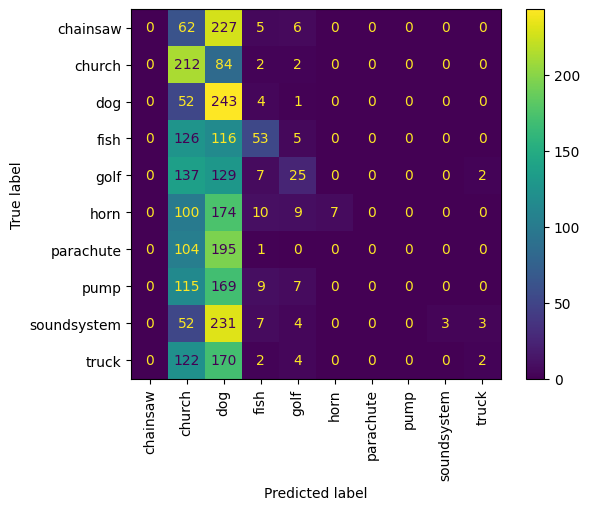

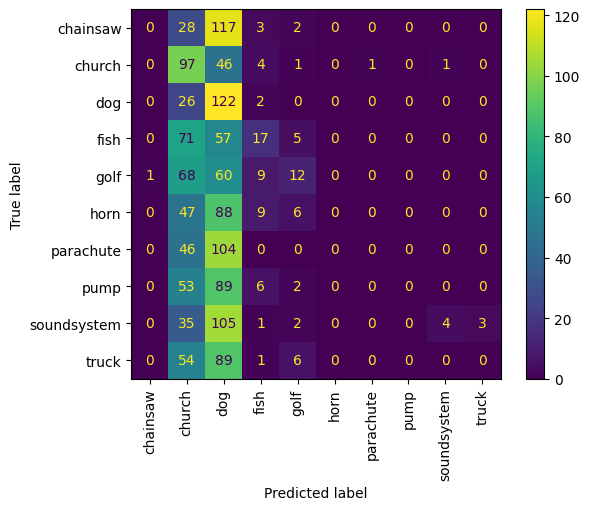

In [32]:
# TODO: classification error for train and test data
train_predictions = get_labels(model_sigleLayer, x_train)
test_predictions = get_labels(model_sigleLayer, x_test)

print("train error:", f"{classification_error(y_train, train_predictions):.4f}")
print("test error", f"{classification_error(y_test, test_predictions):.4f}")
# TODO: confusion matrices for train and test data

display_confusion_matrix(y_train, train_predictions, display_labels=label_names)
display_confusion_matrix(y_test, test_predictions, display_labels=label_names)


### Interpretation

<span style="color:hotpink;">
What's going on ? Is the network learning ?
</span>

<span style="color:hotpink;">I do not think the model has actually learned something, it just tend to predict the result as "chruch" or "dog" among all the imput data</span>

## Neural Networks and PCA

We are seeing how Neural Networks can be _easy_ to build and explain in generic/abstract terms (a bunch of little operators that perform weighted sums of their inputs), but in reality can be really difficult and opaque to steer.

In theory, a couple of well placed neuron layers, with the right hyperparameters, learning rate, loss function, architecture and a good amount of data, can learn to extract information like polynomial features, clusters or even PCA components. But... that's not always the case and sometimes it's not a bad idea to *encourage* the network to go down a certain path.

One way to do this is to pre-process our inputs and do a bit of feature extraction ourselves.

Let's see if we can improve this classification network by using PCA information instead of pixel data.

### Add PCA

We're going to repeat the training, but this time our data is going to be scaled and PCA'd before going into the neural network.

So, the data preparation flow should be:
- Scale data for `PCA`
- Perform `PCA`

We need one `StandardScaler()` object and one `PCA()` object.

The `train` data goes through the `fit_transform()` function of these objects, while the `test` data only goes through `transform()`.

For the `PCA`, we can aim for an explained variance of around $80\%$. This should reduce the number of features significantly to allow us to experiment with our network architecture.

We're working with a dataset that is $3\text{,}000$ rows by $49\text{,}152$ columns. Fitting `PCA` can take a minute.

In [33]:
# TODO: Scale
# TODO: PCA
# TODO: Tensors

std = StandardScaler().set_output(transform="pandas")
pca = PCA(n_components=100).set_output(transform="pandas")

x_pca_train = pca.fit_transform(std.fit_transform(train["pixels"]))
x_pca_test = pca.transform(std.transform(test["pixels"]))

print(pca.n_components_, sum(pca.explained_variance_ratio_))

x_pca_train = Tensor(x_pca_train.values)
y_train = Tensor(train["labels"]).long()

x_pca_test = Tensor(x_pca_test.values)
y_test = Tensor(test["labels"]).long()

x_train.shape

100 0.8190121515658157


torch.Size([3000, 16384])

### Repeat

Re-create model, optimizer, loss function, then re-run the training loop and evaluate.

In [34]:
# TODO: Model, Optimizer and Loss Function
model_multiLayers_01 = nn.Sequential(
  nn.Linear(x_pca_train.shape[1], 200),
  nn.ReLU(),
  nn.Linear(200, 80),
  nn.ReLU(),
  nn.Linear(80, len(label_names)),
)
optim = SGD(model_multiLayers_01.parameters(), lr=0.05, momentum=0.9)

loss_fn = nn.CrossEntropyLoss()
# TODO: Training loop
# TODO: Evaluation

In [35]:
for e in range(64):
  optim.zero_grad()
  preds = model_multiLayers_01(x_pca_train)
  loss = loss_fn(preds, y_train)
  loss.backward()
  optim.step()

  if e%16 == 0:
    train_err = classification_error(y_train, get_labels(model_multiLayers_01, x_pca_train))
    test_err  = classification_error(y_test,  get_labels(model_multiLayers_01, x_pca_test))
    print("training loss:", loss.item(), "training err:", train_err, "test err:", test_err)


training loss: 2.7946765422821045 training err: 0.8386666666666667 test err: 0.8613333333333333
training loss: 1.8268600702285767 training err: 0.6216666666666666 test err: 0.7206666666666667
training loss: 1.4287128448486328 training err: 0.4723333333333334 test err: 0.7093333333333334
training loss: 0.9901418685913086 training err: 0.30433333333333334 test err: 0.7093333333333334


train error: 0.1913
test error 0.7140


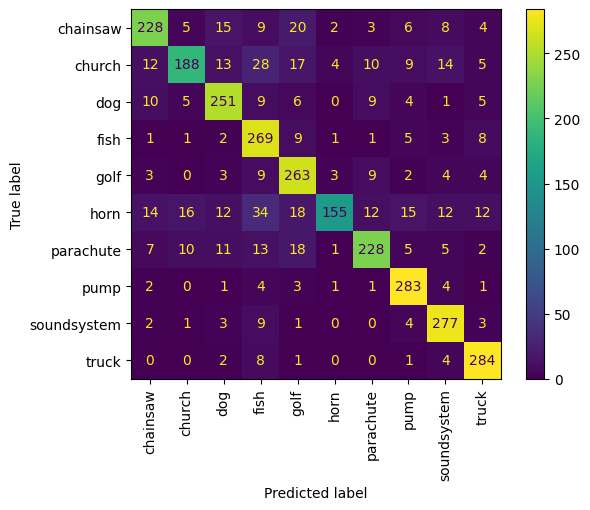

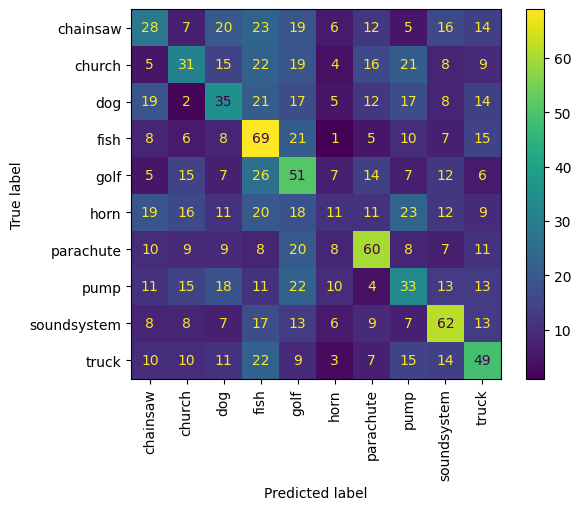

In [36]:

train_predictions = get_labels(model_multiLayers_01, x_pca_train)
test_predictions = get_labels(model_multiLayers_01, x_pca_test)

print("train error:", f"{classification_error(y_train, train_predictions):.4f}")
print("test error", f"{classification_error(y_test, test_predictions):.4f}")

display_confusion_matrix(y_train, train_predictions, display_labels=label_names)
display_confusion_matrix(y_test, test_predictions, display_labels=label_names)

In [48]:
model_multiLayers_02 = nn.Sequential(
  nn.Dropout(0.5),
  nn.Linear(x_pca_train.shape[1], 80),
  nn.BatchNorm1d(80),
  nn.ReLU(),
  
  nn.Dropout(0.5),
  nn.LayerNorm(80),
  nn.Linear(80, 40),
  # nn.BatchNorm1d(x_pca_train.shape[1]//2),
  nn.ReLU(),


  nn.Dropout(0.5),
  nn.LayerNorm(40),
  nn.Linear(40, len(label_names)),
)
optim = SGD(model_multiLayers_02.parameters(), lr=0.05, momentum=0.6)

loss_fn = nn.CrossEntropyLoss()

for e in range(200):
  optim.zero_grad()
  preds = model_multiLayers_02(x_pca_train)
  loss = loss_fn(preds, y_train)
  loss.backward()
  optim.step()

  if e%16 == 0:
    train_err = classification_error(y_train, get_labels(model_multiLayers_02, x_pca_train))
    test_err  = classification_error(y_test,  get_labels(model_multiLayers_02, x_pca_test))
    print("training loss:", loss.item(), "training err:", train_err, "test err:", test_err)


training loss: 2.4376471042633057 training err: 0.8776666666666667 test err: 0.882
training loss: 1.9894498586654663 training err: 0.7026666666666667 test err: 0.7586666666666666
training loss: 1.856085181236267 training err: 0.638 test err: 0.7426666666666666
training loss: 1.7417120933532715 training err: 0.585 test err: 0.7273333333333334
training loss: 1.6280415058135986 training err: 0.54 test err: 0.7293333333333334
training loss: 1.5067611932754517 training err: 0.4773333333333334 test err: 0.7326666666666667
training loss: 1.3790409564971924 training err: 0.43933333333333335 test err: 0.7406666666666666
training loss: 1.253290057182312 training err: 0.3873333333333333 test err: 0.736
training loss: 1.1460444927215576 training err: 0.3596666666666667 test err: 0.7306666666666667
training loss: 1.0417555570602417 training err: 0.29866666666666664 test err: 0.73
training loss: 0.9341608285903931 training err: 0.2666666666666667 test err: 0.7406666666666666
training loss: 0.8694629

train error: 0.2200
test error 0.7447


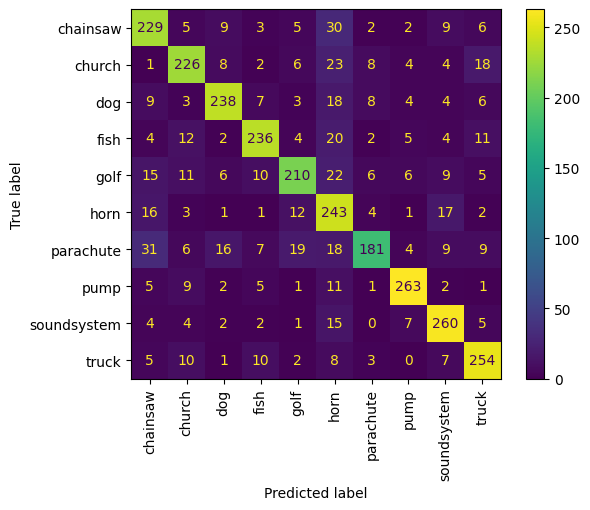

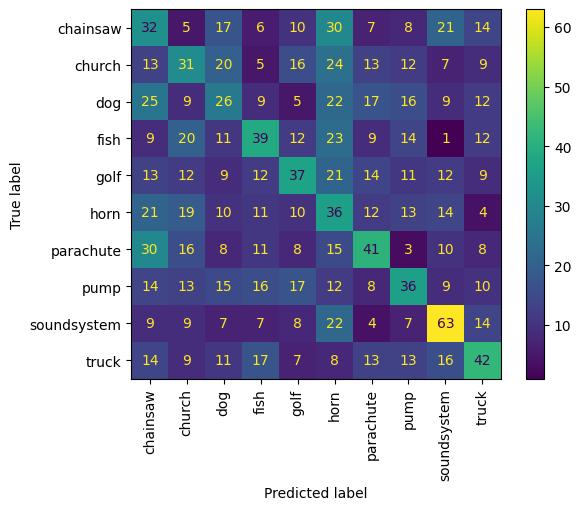

In [49]:
train_predictions = get_labels(model_multiLayers_02, x_pca_train)
test_predictions = get_labels(model_multiLayers_02, x_pca_test)

print("train error:", f"{classification_error(y_train, train_predictions):.4f}")
print("test error", f"{classification_error(y_test, test_predictions):.4f}")

display_confusion_matrix(y_train, train_predictions, display_labels=label_names)
display_confusion_matrix(y_test, test_predictions, display_labels=label_names)

### Interpretation

<span style="color:hotpink;">
So... What happens ?<br>
How does training on the <code>PCA</code> data compare to training on the regular data ?

What else does <code>PCA</code> afford us in this case ? ...<br>
How does adding extra layers in the original network compare to adding extra layers in the <code>PCA</code> network?
</span>

<span style="color:hotpink;">
Both models I built overfit: the training error keeps decreasing but the test error, they seem overfit to the traning data:( <br>
Using PCA data for training could reduce the number of input features and save training time.<br>
Compared with adding extra layers to the original network, adding extra layers to the PCA network reduces the complexity of the neural network (the number of parameters in the model).<br>

</span>